# 04 — Interpretability + doctor-facing patient demo

This notebook turns the frozen `03b` model into the hackathon demo.

For one pre-operative patient, it:

1. reconstructs the longitudinal lab and medication history;
2. reconstructs prior valve history from the Qwen output;
3. evaluates observed candidate valve configurations;
4. produces survival curves and model-estimated event-free durability in years;
5. explains patient-history drivers using grouped feature occlusion;
6. explains why candidate B differs from candidate A using an exact Shapley decomposition over procedure type, model, size, and position.

The model is a **semi-synthetic proof of concept**, not a clinically validated treatment recommendation system.

In [19]:
from pathlib import Path
from itertools import combinations
import ast
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

MODEL_DIR = Path("preop_valve_survival_model_03b")
MODEL_PATH = MODEL_DIR / "personalized_valve_survival_model.pt"
PREPROC_PATH = MODEL_DIR / "preprocessing.json"
METRICS_PATH = MODEL_DIR / "metrics.json"

SYNTH_DIR = Path("synthetic_heterogeneous_preop_v5")
CANDIDATE_CATALOG_CSV = SYNTH_DIR / "observed_qwen_candidate_catalog_v5.csv"

REAL_TIMELINE_CSV = Path("real_17_patient_year_lab_med_with_qwen_anchor.csv")
QWEN_HISTORY_PKL = Path("qwen_prior_valve_history_17.pkl")

DEMO_OUT = Path("doctor_facing_demo")
DEMO_OUT.mkdir(exist_ok=True)

required = [
    MODEL_PATH,
    PREPROC_PATH,
    CANDIDATE_CATALOG_CSV,
    REAL_TIMELINE_CSV,
    QWEN_HISTORY_PKL,
]

missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing required file(s):\n  - "
        + "\n  - ".join(missing)
        + "\nRun the merge notebook, 02e, and 03b first."
    )

Device: cuda


In [20]:
# ============================================================
# Load checkpoint + preprocessing contract
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
)

with open(PREPROC_PATH) as f:
    preproc = json.load(f)

LAB_COLS = list(checkpoint["lab_features"])
MED_COLS = list(checkpoint["medication_features"])
HISTORY_COLS = list(checkpoint["history_features"])
CANDIDATE_CAT_COLS = list(checkpoint["candidate_cat_features"])
CANDIDATE_NUM_COLS = list(checkpoint["candidate_num_features"])

candidate_vocabs = checkpoint["candidate_vocabs"]

N_BINS = int(checkpoint["n_bins"])
BIN_WIDTH_YEARS = float(checkpoint["bin_width_years"])
HORIZON_YEARS = N_BINS * BIN_WIDTH_YEARS

lab_mean = pd.Series(preproc["lab_mean"]).reindex(LAB_COLS).astype(float)
lab_std = pd.Series(preproc["lab_std"]).reindex(LAB_COLS).astype(float)

history_mean = pd.Series(preproc["history_mean"]).reindex(HISTORY_COLS).astype(float)
history_std = pd.Series(preproc["history_std"]).reindex(HISTORY_COLS).astype(float)

candidate_num_mean = (
    pd.Series(preproc["candidate_num_mean"])
    .reindex(CANDIDATE_NUM_COLS)
    .astype(float)
)

candidate_num_std = (
    pd.Series(preproc["candidate_num_std"])
    .reindex(CANDIDATE_NUM_COLS)
    .astype(float)
)

LAB_INPUT_DIM = len(LAB_COLS) * 2 + 1
MED_INPUT_DIM = len(MED_COLS) * 2 + 1
HISTORY_INPUT_DIM = len(HISTORY_COLS) * 2
CANDIDATE_NUM_INPUT_DIM = len(CANDIDATE_NUM_COLS) * 2

print("Horizon:", HORIZON_YEARS, "years")
print("Labs / meds / history:", len(LAB_COLS), len(MED_COLS), len(HISTORY_COLS))

if METRICS_PATH.exists():
    with open(METRICS_PATH) as f:
        saved_metrics = json.load(f)

    print("\nFrozen 03b metrics:")
    print(json.dumps(saved_metrics, indent=2))

Horizon: 12.0 years
Labs / meds / history: 30 15 7

Frozen 03b metrics:
{
  "test_harrell_c_index": 0.862787207973678,
  "mean_within_patient_spearman": 0.8226666666666667,
  "top1_candidate_accuracy": 0.76,
  "pairwise_candidate_ranking_accuracy": 0.8833333333333333,
  "global_hidden_truth_spearman": 0.9083178564384901,
  "global_hidden_truth_pearson": 0.9416687753922589
}


In [21]:
# ============================================================
# Reconstruct frozen 03b architecture
# ============================================================

class SequenceGRUEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )

        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
            nn.LayerNorm(output_dim),
        )

    def forward(self, x, lengths):
        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, h = self.gru(packed)
        return self.proj(h[-1])


class CandidateValveEncoder(nn.Module):
    def __init__(
        self,
        n_procedure,
        n_model,
        n_position,
        numeric_dim,
        output_dim=48,
    ):
        super().__init__()

        self.procedure_emb = nn.Embedding(n_procedure, 4)
        self.model_emb = nn.Embedding(n_model, 12)
        self.position_emb = nn.Embedding(n_position, 3)

        in_dim = 4 + 12 + 3 + numeric_dim

        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, output_dim),
            nn.ReLU(),
            nn.LayerNorm(output_dim),
        )

    def forward(self, procedure, model, position, numeric):
        x = torch.cat(
            [
                self.procedure_emb(procedure),
                self.model_emb(model),
                self.position_emb(position),
                numeric,
            ],
            dim=1,
        )

        return self.mlp(x)


class InteractionAwareValveSurvivalModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lab_encoder = SequenceGRUEncoder(
            input_dim=LAB_INPUT_DIM,
            hidden_dim=64,
            output_dim=32,
        )

        self.med_encoder = SequenceGRUEncoder(
            input_dim=MED_INPUT_DIM,
            hidden_dim=48,
            output_dim=24,
        )

        self.history_encoder = nn.Sequential(
            nn.Linear(HISTORY_INPUT_DIM, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 20),
            nn.ReLU(),
            nn.LayerNorm(20),
        )

        self.patient_projection = nn.Sequential(
            nn.Linear(32 + 24 + 20, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 48),
            nn.ReLU(),
            nn.LayerNorm(48),
        )

        self.candidate_encoder = CandidateValveEncoder(
            n_procedure=len(candidate_vocabs["candidate_procedure_type"]),
            n_model=len(candidate_vocabs["candidate_valve_model"]),
            n_position=len(candidate_vocabs["candidate_valve_position"]),
            numeric_dim=CANDIDATE_NUM_INPUT_DIM,
            output_dim=48,
        )

        self.interaction_fusion = nn.Sequential(
            nn.Linear(48 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
        )

        self.survival_head = nn.Linear(64, N_BINS)

    def forward(self, batch, return_embeddings=False):
        z_lab = self.lab_encoder(
            batch["lab"],
            batch["lab_lengths"],
        )

        z_med = self.med_encoder(
            batch["med"],
            batch["med_lengths"],
        )

        z_history = self.history_encoder(batch["history"])

        z_patient = self.patient_projection(
            torch.cat(
                [z_lab, z_med, z_history],
                dim=1,
            )
        )

        z_valve = self.candidate_encoder(
            batch["candidate_procedure"],
            batch["candidate_model"],
            batch["candidate_position"],
            batch["candidate_numeric"],
        )

        z_product = z_patient * z_valve
        z_absdiff = torch.abs(z_patient - z_valve)

        interaction = torch.cat(
            [
                z_patient,
                z_valve,
                z_product,
                z_absdiff,
            ],
            dim=1,
        )

        fused = self.interaction_fusion(interaction)
        hazard_logits = self.survival_head(fused)

        if return_embeddings:
            return {
                "hazard_logits": hazard_logits,
                "z_patient": z_patient,
                "z_valve": z_valve,
            }

        return hazard_logits


model = InteractionAwareValveSurvivalModel().to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("✓ Frozen 03b model loaded")

✓ Frozen 03b model loaded


In [22]:
# ============================================================
# Model input / prediction helpers
# ============================================================

def clean_model_name(x):
    if pd.isna(x):
        return "UNKNOWN_MODEL"

    x = str(x).strip()

    if x == "" or x.lower() in {"name", "nan", "none", "unknown"}:
        return "UNKNOWN_MODEL"

    return x


def encode_category(value, vocab):
    if pd.isna(value):
        return 0

    value = str(value).strip()

    if value == "" or value.lower() in {"nan", "none"}:
        return 0

    return int(vocab.get(value, 0))


def transform_history_vector(history_dict):
    raw = pd.Series({
        c: history_dict.get(c, np.nan)
        for c in HISTORY_COLS
    })

    raw = pd.to_numeric(
        raw,
        errors="coerce",
    )

    mask = raw.notna().astype(np.float32)

    z = (
        (raw - history_mean)
        / history_std
    ).fillna(0.0).astype(np.float32)

    x = np.concatenate(
        [
            z.to_numpy(),
            mask.to_numpy(),
        ]
    ).astype(np.float32)

    return torch.tensor(
        x,
        dtype=torch.float32,
    )


def transform_candidate_row(candidate_row):
    procedure = encode_category(
        candidate_row["candidate_procedure_type"],
        candidate_vocabs["candidate_procedure_type"],
    )

    model_idx = encode_category(
        clean_model_name(candidate_row["candidate_valve_model"]),
        candidate_vocabs["candidate_valve_model"],
    )

    position = encode_category(
        candidate_row["candidate_valve_position"],
        candidate_vocabs["candidate_valve_position"],
    )

    raw_num = pd.Series({
        c: candidate_row.get(c, np.nan)
        for c in CANDIDATE_NUM_COLS
    })

    raw_num = pd.to_numeric(
        raw_num,
        errors="coerce",
    )

    mask = raw_num.notna().astype(np.float32)

    z = (
        (raw_num - candidate_num_mean)
        / candidate_num_std
    ).fillna(0.0).astype(np.float32)

    numeric = np.concatenate(
        [
            z.to_numpy(),
            mask.to_numpy(),
        ]
    ).astype(np.float32)

    return {
        "procedure": procedure,
        "model": model_idx,
        "position": position,
        "numeric": torch.tensor(
            numeric,
            dtype=torch.float32,
        ),
    }


def hazards_to_survival(hazard_logits):
    hazards = torch.sigmoid(hazard_logits)

    survival = torch.cumprod(
        1.0 - hazards,
        dim=1,
    )

    survival_start = torch.cat(
        [
            torch.ones(
                (survival.shape[0], 1),
                dtype=survival.dtype,
                device=survival.device,
            ),
            survival[:, :-1],
        ],
        dim=1,
    )

    rmst = (
        survival_start.sum(dim=1)
        * BIN_WIDTH_YEARS
    )

    return hazards, survival, rmst


def median_survival_years(survival_vector):
    survival_vector = np.asarray(
        survival_vector,
        dtype=float,
    )

    idx = np.where(
        survival_vector <= 0.5
    )[0]

    if len(idx) == 0:
        return np.nan

    return (int(idx[0]) + 1) * BIN_WIDTH_YEARS


def survival_at(survival_vector, year):
    idx = int(
        math.ceil(
            year / BIN_WIDTH_YEARS
        ) - 1
    )

    idx = min(
        max(idx, 0),
        len(survival_vector) - 1,
    )

    return float(
        survival_vector[idx]
    )


def make_single_batch(
    prepared_patient,
    history_tensor,
    candidate_row,
):
    candidate = transform_candidate_row(
        candidate_row
    )

    return {
        "lab": prepared_patient["lab"].unsqueeze(0).to(DEVICE),

        "lab_lengths": torch.tensor(
            [prepared_patient["lab"].shape[0]],
            dtype=torch.long,
            device=DEVICE,
        ),

        "med": prepared_patient["med"].unsqueeze(0).to(DEVICE),

        "med_lengths": torch.tensor(
            [prepared_patient["med"].shape[0]],
            dtype=torch.long,
            device=DEVICE,
        ),

        "history": history_tensor.unsqueeze(0).to(DEVICE),

        "candidate_procedure": torch.tensor(
            [candidate["procedure"]],
            dtype=torch.long,
            device=DEVICE,
        ),

        "candidate_model": torch.tensor(
            [candidate["model"]],
            dtype=torch.long,
            device=DEVICE,
        ),

        "candidate_position": torch.tensor(
            [candidate["position"]],
            dtype=torch.long,
            device=DEVICE,
        ),

        "candidate_numeric": candidate["numeric"].unsqueeze(0).to(DEVICE),
    }


def predict_candidate(
    prepared_patient,
    history_tensor,
    candidate_row,
):
    batch = make_single_batch(
        prepared_patient,
        history_tensor,
        candidate_row,
    )

    with torch.no_grad():
        logits = model(batch)
        _, survival, rmst = hazards_to_survival(logits)

    survival_np = (
        survival[0]
        .detach()
        .cpu()
        .numpy()
    )

    return {
        "rmst_years": float(rmst[0].detach().cpu()),
        "median_survival_years": median_survival_years(survival_np),
        "survival_5y": survival_at(survival_np, 5),
        "survival_8y": survival_at(survival_np, 8),
        "survival_10y": survival_at(survival_np, 10),
        "survival_curve": survival_np,
    }

In [23]:
# ============================================================
# Load real patient library + candidate library
# ============================================================

real_timeline = pd.read_csv(
    REAL_TIMELINE_CSV
)

qwen_history = pd.read_pickle(
    QWEN_HISTORY_PKL
)

candidate_catalog = pd.read_csv(
    CANDIDATE_CATALOG_CSV
)

candidate_catalog["candidate_valve_model"] = (
    candidate_catalog["candidate_valve_model"]
    .apply(clean_model_name)
)

real_timeline["Year"] = pd.to_numeric(
    real_timeline["Year"],
    errors="coerce",
)

real_patients = sorted(
    set(real_timeline["Patient"].dropna())
    & set(qwen_history["Patient"].dropna())
)

print("Real patients available:", len(real_patients))
print("Observed candidate configurations:", len(candidate_catalog))

display(
    candidate_catalog[
        [
            "candidate_id",
            "candidate_procedure_type",
            "candidate_valve_model",
            "candidate_valve_size_mm",
            "candidate_valve_position",
            "observed_frequency",
        ]
    ]
    .sort_values(
        "observed_frequency",
        ascending=False,
    )
    .head(20)
)

Real patients available: 17
Observed candidate configurations: 16


,candidate_id,candidate_procedure_type,candidate_valve_model,candidate_valve_size_mm,candidate_valve_position,observed_frequency
10,OBS_011,SAVR,UNKNOWN_MODEL,NaN,aortic,4
0,OBS_001,SAVR,23 TRIFECTA,NaN,aortic,1
2,OBS_003,SAVR,Carpentier-Edwards bovine pericardial,21.0,aortic,1
1,OBS_002,SAVR,23-mm pericardial prosthesis,23.0,aortic,1
4,OBS_005,SAVR,Carpentier-Edwards bovine pericardial aortic v...,23.0,aortic,1
5,OBS_006,SAVR,Carpentier-Edwards pericardial,25.0,aortic,1
6,OBS_007,SAVR,Carpentier-Edwards prosthetic aortic valve (si...,25.0,aortic,1
3,OBS_004,SAVR,Carpentier-Edwards bovine pericardial,23.0,aortic,1
7,OBS_008,SAVR,Perimount,23.0,aortic,1
8,OBS_009,SAVR,Trifecta,23.0,aortic,1


In [24]:
# ============================================================
# Choose a real patient for the live demo
#
# Change REAL_PATIENT_ID manually if desired.
# Default = patient with the longest trajectory.
# ============================================================

trajectory_lengths = (
    real_timeline[
        real_timeline["Patient"].isin(real_patients)
    ]
    .groupby("Patient")
    .size()
    .sort_values(ascending=False)
)

REAL_PATIENT_ID = trajectory_lengths.index[0]

print("Demo patient:", REAL_PATIENT_ID)
print(
    "Recorded yearly timepoints:",
    int(
        trajectory_lengths.loc[
            REAL_PATIENT_ID
        ]
    )
)

Demo patient: Patient_101
Recorded yearly timepoints: 21


In [25]:
# ============================================================
# Prepare real pre-operative trajectory
#
# Training convention:
# hypothetical procedure = one year after last donor observation.
# We use the same convention here.
# ============================================================

def prepare_real_patient_trajectory(patient_id):
    g = (
        real_timeline[
            real_timeline["Patient"].eq(patient_id)
        ]
        .dropna(subset=["Year"])
        .sort_values("Year")
        .copy()
    )

    if len(g) == 0:
        raise ValueError(
            f"No real trajectory for {patient_id}"
        )

    surgery_year = float(
        g["Year"].max() + 1
    )

    time_months = (
        (g["Year"].astype(float) - surgery_year)
        * 12.0
    )

    lab_raw = (
        g[LAB_COLS]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
    )

    lab_mask = (
        lab_raw
        .notna()
        .astype(np.float32)
    )

    lab_z = (
        (lab_raw - lab_mean)
        / lab_std
    ).fillna(0.0).astype(np.float32)

    med_raw = (
        g[MED_COLS]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
    )

    med_mask = (
        med_raw
        .notna()
        .astype(np.float32)
    )

    med_filled = (
        med_raw
        .fillna(0.0)
        .astype(np.float32)
    )

    time_channel = (
        time_months
        .to_numpy()
        .reshape(-1, 1)
        / 120.0
    ).astype(np.float32)

    lab_x = np.concatenate(
        [
            lab_z.to_numpy(),
            lab_mask.to_numpy(),
            time_channel,
        ],
        axis=1,
    ).astype(np.float32)

    med_x = np.concatenate(
        [
            med_filled.to_numpy(),
            med_mask.to_numpy(),
            time_channel,
        ],
        axis=1,
    ).astype(np.float32)

    return {
        "patient_id": patient_id,
        "surgery_year": surgery_year,
        "source_table": g,
        "lab_raw": lab_raw,
        "med_raw": med_raw,
        "lab": torch.tensor(
            lab_x,
            dtype=torch.float32,
        ),
        "med": torch.tensor(
            med_x,
            dtype=torch.float32,
        ),
    }


prepared_patient = prepare_real_patient_trajectory(
    REAL_PATIENT_ID
)

print(
    "Hypothetical surgery year:",
    prepared_patient["surgery_year"],
)

print(
    "Trajectory length:",
    prepared_patient["lab"].shape[0],
)

display(
    prepared_patient["source_table"][
        [
            "Patient",
            "Year",
            "labs_observed",
            "medications_observed",
        ]
        + LAB_COLS[:5]
        + MED_COLS[:5]
    ]
)

Hypothetical surgery year: 2026.0
Trajectory length: 21


,Patient,Year,labs_observed,medications_observed,lab__ALT,lab__APTT,lab__AST,lab__Albumin,lab__Alkaline Phosphatase,med__ace_inhibitor__present,med__antiarrhythmic__present,med__anticoagulant__present,med__antiplatelet__present,med__arb__present
0,Patient_101,2003,0,1,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,1.0,0.0
1,Patient_101,2005,1,1,NaN,31.65,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
2,Patient_101,2006,1,1,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
3,Patient_101,2007,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Patient_101,2008,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Patient_101,2009,1,1,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
6,Patient_101,2011,0,1,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0
7,Patient_101,2012,0,1,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0
8,Patient_101,2013,0,1,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
9,Patient_101,2014,0,1,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [26]:
# ============================================================
# Reconstruct prior valve history from Qwen
# ============================================================

def listify(x):
    if isinstance(x, list):
        return x

    if x is None:
        return []

    if isinstance(x, float) and np.isnan(x):
        return []

    try:
        y = ast.literal_eval(str(x))
        return y if isinstance(y, list) else []
    except Exception:
        return []


def as_bool(x):
    if x is True:
        return True

    if x is False or x is None:
        return False

    return (
        str(x).strip().lower()
        in {"true", "1", "yes", "y"}
    )


def prior_history_from_qwen(patient_id):
    rows = qwen_history[
        qwen_history["Patient"].eq(patient_id)
    ]

    if len(rows) == 0:
        raise KeyError(
            f"No Qwen history for {patient_id}"
        )

    r = rows.iloc[0]

    types = [
        str(x).upper().strip()
        for x in listify(
            r.get("procedure_types", [])
        )
    ]

    models = [
        clean_model_name(x)
        for x in listify(
            r.get("valve_models", [])
        )
    ]

    known_models = [
        x
        for x in models
        if x != "UNKNOWN_MODEL"
    ]

    sizes = pd.to_numeric(
        pd.Series(
            listify(
                r.get("valve_sizes_mm", [])
            )
        ),
        errors="coerce",
    ).dropna()

    history = {
        "prior_valve_count": int(
            sum(
                t in {"SAVR", "TAVR"}
                for t in types
            )
        ),

        "prior_has_SAVR": int(
            "SAVR" in types
        ),

        "prior_has_TAVR": int(
            "TAVR" in types
        ),

        "prior_redo_count": int(
            sum(
                as_bool(x)
                for x in listify(
                    r.get("redo_flags", [])
                )
            )
        ),

        "prior_ViV_count": int(
            sum(
                as_bool(x)
                for x in listify(
                    r.get("ViV_flags", [])
                )
            )
        ),

        "prior_latest_valve_size_mm": (
            float(sizes.iloc[-1])
            if len(sizes)
            else np.nan
        ),

        "prior_known_model_count": int(
            len(known_models)
        ),
    }

    readable = {
        "procedure_types": types,
        "valve_models": models,
        "valve_sizes_mm": sizes.tolist(),
    }

    return history, readable


history_dict, readable_history = prior_history_from_qwen(
    REAL_PATIENT_ID
)

history_tensor = transform_history_vector(
    history_dict
)

print("Qwen prior valve history:")
print(
    json.dumps(
        readable_history,
        indent=2,
    )
)

print("\nModel history vector:")
print(
    json.dumps(
        {
            k: (
                None
                if pd.isna(v)
                else float(v)
            )
            for k, v
            in history_dict.items()
        },
        indent=2,
    )
)

Qwen prior valve history:
{
  "procedure_types": [
    "TAVR"
  ],
  "valve_models": [
    "Edwards-Sapien"
  ],
  "valve_sizes_mm": [
    29
  ]
}

Model history vector:
{
  "prior_valve_count": 1.0,
  "prior_has_SAVR": 0.0,
  "prior_has_TAVR": 1.0,
  "prior_redo_count": 0.0,
  "prior_ViV_count": 0.0,
  "prior_latest_valve_size_mm": 29.0,
  "prior_known_model_count": 1.0
}


In [27]:
# ============================================================
# Build candidate set from ALL observed Qwen configurations
# ============================================================

candidate_demo = (
    candidate_catalog
    .sort_values(
        [
            "candidate_procedure_type",
            "candidate_valve_size_mm",
            "observed_frequency",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
    .drop_duplicates(
        "candidate_id"
    )
    .reset_index(
        drop=True
    )
    .copy()
)

candidate_demo[
    "candidate_valve_model"
] = (
    candidate_demo[
        "candidate_valve_model"
    ]
    .apply(
        clean_model_name
    )
)

print(
    "Candidate configurations:",
    len(candidate_demo)
)

print(
    "\nProcedure-type coverage:"
)

display(
    candidate_demo[
        "candidate_procedure_type"
    ]
    .value_counts()
    .rename_axis(
        "procedure_type"
    )
    .reset_index(
        name="n_candidates"
    )
)

display(
    candidate_demo[
        [
            "candidate_id",
            "candidate_procedure_type",
            "candidate_valve_model",
            "candidate_valve_size_mm",
            "candidate_valve_position",
            "observed_frequency",
        ]
    ]
)

Candidate configurations: 16

Procedure-type coverage:


,procedure_type,n_candidates
0,SAVR,12
1,TAVR,4


,candidate_id,candidate_procedure_type,candidate_valve_model,candidate_valve_size_mm,candidate_valve_position,observed_frequency
0,OBS_003,SAVR,Carpentier-Edwards bovine pericardial,21.0,aortic,1
1,OBS_002,SAVR,23-mm pericardial prosthesis,23.0,aortic,1
2,OBS_004,SAVR,Carpentier-Edwards bovine pericardial,23.0,aortic,1
3,OBS_005,SAVR,Carpentier-Edwards bovine pericardial aortic v...,23.0,aortic,1
4,OBS_008,SAVR,Perimount,23.0,aortic,1
5,OBS_009,SAVR,Trifecta,23.0,aortic,1
6,OBS_010,SAVR,Trifecta valve,23.0,aortic,1
7,OBS_012,SAVR,trifecta,23.0,aortic,1
8,OBS_006,SAVR,Carpentier-Edwards pericardial,25.0,aortic,1
9,OBS_007,SAVR,Carpentier-Edwards prosthetic aortic valve (si...,25.0,aortic,1


In [28]:
# ============================================================
# Predict durability for every candidate
# ============================================================

candidate_predictions = []

for _, candidate in candidate_demo.iterrows():
    pred = predict_candidate(
        prepared_patient,
        history_tensor,
        candidate,
    )

    candidate_predictions.append({
        "candidate_id": candidate["candidate_id"],
        "procedure_type": candidate["candidate_procedure_type"],
        "valve_model": candidate["candidate_valve_model"],
        "valve_size_mm": candidate["candidate_valve_size_mm"],
        "valve_position": candidate["candidate_valve_position"],

        "estimated_event_free_years_12y_rmst": pred["rmst_years"],
        "median_survival_years": pred["median_survival_years"],

        "survival_5y": pred["survival_5y"],
        "survival_8y": pred["survival_8y"],
        "survival_10y": pred["survival_10y"],

        "survival_curve": pred["survival_curve"],
    })

comparison_df = (
    pd.DataFrame(candidate_predictions)
    .sort_values(
        "estimated_event_free_years_12y_rmst",
        ascending=False,
    )
    .reset_index(drop=True)
)

doctor_table = comparison_df[
    [
        "candidate_id",
        "procedure_type",
        "valve_model",
        "valve_size_mm",
        "estimated_event_free_years_12y_rmst",
        "median_survival_years",
        "survival_5y",
        "survival_8y",
        "survival_10y",
    ]
].copy()

for c in [
    "estimated_event_free_years_12y_rmst",
    "median_survival_years",
]:
    doctor_table[c] = doctor_table[c].round(2)

for c in [
    "survival_5y",
    "survival_8y",
    "survival_10y",
]:
    doctor_table[c] = (
        100 * doctor_table[c]
    ).round(1)

print("Doctor-facing candidate comparison")
print("Patient:", REAL_PATIENT_ID)

print(
    "Primary duration measure: restricted mean event-free years "
    f"within the {HORIZON_YEARS:.0f}-year model horizon."
)

display(doctor_table)

Doctor-facing candidate comparison
Patient: Patient_101
Primary duration measure: restricted mean event-free years within the 12-year model horizon.


,candidate_id,procedure_type,valve_model,valve_size_mm,estimated_event_free_years_12y_rmst,median_survival_years,survival_5y,survival_8y,survival_10y
0,OBS_013,TAVR,Edwards-Sapien,29.0,10.75,11.0,98.3,92.3,62.8
1,OBS_006,SAVR,Carpentier-Edwards pericardial,25.0,10.46,11.0,98.7,91.3,53.0
2,OBS_014,TAVR,UNKNOWN_MODEL,26.0,10.41,10.0,98.6,91.1,49.5
3,OBS_007,SAVR,Carpentier-Edwards prosthetic aortic valve (si...,25.0,10.25,10.0,98.7,89.9,45.3
4,OBS_001,SAVR,23 TRIFECTA,NaN,10.04,10.0,98.8,85.9,39.4
5,OBS_005,SAVR,Carpentier-Edwards bovine pericardial aortic v...,23.0,9.65,10.0,98.1,79.5,29.6
6,OBS_004,SAVR,Carpentier-Edwards bovine pericardial,23.0,9.58,9.0,97.8,79.6,28.3
7,OBS_016,TAVR,UNKNOWN_MODEL,NaN,9.45,9.0,97.8,79.9,21.5
8,OBS_009,SAVR,Trifecta,23.0,9.34,9.0,97.2,69.8,23.4
9,OBS_011,SAVR,UNKNOWN_MODEL,NaN,9.19,9.0,97.5,72.1,16.6


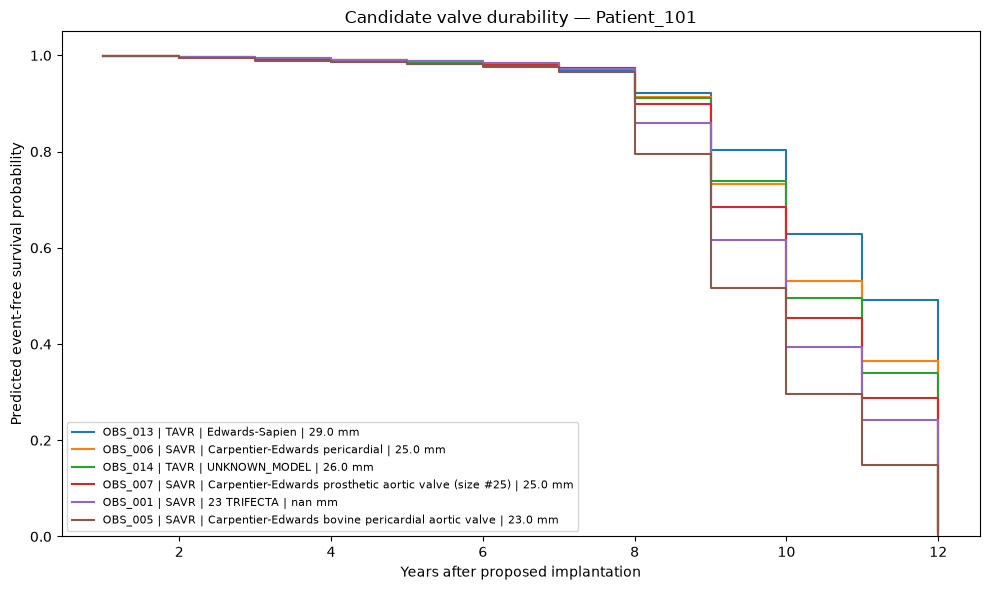

In [29]:
# ============================================================
# Plot candidate survival curves
# ============================================================

plt.figure(
    figsize=(10, 6)
)

years = (
    np.arange(1, N_BINS + 1)
    * BIN_WIDTH_YEARS
)

for _, row in comparison_df.head(6).iterrows():
    label = (
        f"{row['candidate_id']} | "
        f"{row['procedure_type']} | "
        f"{row['valve_model']} | "
        f"{row['valve_size_mm']} mm"
    )

    plt.step(
        years,
        row["survival_curve"],
        where="post",
        label=label,
    )

plt.xlabel(
    "Years after proposed implantation"
)

plt.ylabel(
    "Predicted event-free survival probability"
)

plt.title(
    f"Candidate valve durability — {REAL_PATIENT_ID}"
)

plt.ylim(0, 1.05)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Interpretation convention

The main duration value is **12-year restricted mean event-free survival time (RMST)**:

\[
\mathrm{RMST}_{12}
=
\int_0^{12} S(t)\,dt
\]

This remains defined even when predicted survival never falls below 50% within the modeled horizon.

The explanations below describe **model sensitivity**, not causal effects.

In [30]:
# ============================================================
# Patient-history interpretability by grouped occlusion
#
# Signed effect:
# baseline RMST - occluded RMST
#
# positive -> observed patient pattern raises predicted RMST
# negative -> observed patient pattern lowers predicted RMST
# ============================================================

REFERENCE_CANDIDATE_ID = comparison_df.iloc[0]["candidate_id"]

reference_candidate = (
    candidate_demo[
        candidate_demo["candidate_id"].eq(
            REFERENCE_CANDIDATE_ID
        )
    ]
    .iloc[0]
)

baseline_rmst = predict_candidate(
    prepared_patient,
    history_tensor,
    reference_candidate,
)["rmst_years"]

print(
    "Interpretability reference candidate:",
    REFERENCE_CANDIDATE_ID,
)

print(
    "Baseline model-estimated RMST:",
    round(baseline_rmst, 3),
    "years",
)


def predict_modified(
    lab_tensor,
    med_tensor,
    hist_tensor,
):
    modified_patient = {
        "lab": lab_tensor,
        "med": med_tensor,
    }

    return predict_candidate(
        modified_patient,
        hist_tensor,
        reference_candidate,
    )["rmst_years"]


driver_rows = []

# ------------------------------------------------------------
# Labs: set standardized values to training mean (z=0)
# but preserve the measurement/missingness mask.
# ------------------------------------------------------------

for j, feature in enumerate(LAB_COLS):
    lab_mod = prepared_patient["lab"].clone()
    med_mod = prepared_patient["med"].clone()

    lab_mod[:, j] = 0.0

    rmst_occ = predict_modified(
        lab_mod,
        med_mod,
        history_tensor,
    )

    driver_rows.append({
        "modality": "lab",
        "feature": feature.replace("lab__", ""),
        "effect_years": baseline_rmst - rmst_occ,
    })


# ------------------------------------------------------------
# Medications: replace exposure with 0, preserve observation mask.
# ------------------------------------------------------------

for j, feature in enumerate(MED_COLS):
    lab_mod = prepared_patient["lab"].clone()
    med_mod = prepared_patient["med"].clone()

    med_mod[:, j] = 0.0

    rmst_occ = predict_modified(
        lab_mod,
        med_mod,
        history_tensor,
    )

    driver_rows.append({
        "modality": "medication",
        "feature": (
            feature
            .replace("med__", "")
            .replace("__present", "")
        ),
        "effect_years": baseline_rmst - rmst_occ,
    })


# ------------------------------------------------------------
# Prior valve-history features: set standardized value to mean,
# preserve availability mask.
# ------------------------------------------------------------

for j, feature in enumerate(HISTORY_COLS):
    h_mod = history_tensor.clone()
    h_mod[j] = 0.0

    rmst_occ = predict_modified(
        prepared_patient["lab"],
        prepared_patient["med"],
        h_mod,
    )

    driver_rows.append({
        "modality": "prior valve history",
        "feature": feature,
        "effect_years": baseline_rmst - rmst_occ,
    })


driver_df = pd.DataFrame(driver_rows)

driver_df["absolute_effect_years"] = (
    driver_df["effect_years"].abs()
)

driver_df = (
    driver_df
    .sort_values(
        "absolute_effect_years",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Largest model-sensitive patient-history drivers"
)

display(
    driver_df.head(15)[
        [
            "modality",
            "feature",
            "effect_years",
            "absolute_effect_years",
        ]
    ]
)

Interpretability reference candidate: OBS_013
Baseline model-estimated RMST: 10.753 years
Largest model-sensitive patient-history drivers


,modality,feature,effect_years,absolute_effect_years
0,prior valve history,prior_has_SAVR,0.187790,0.187790
1,prior valve history,prior_latest_valve_size_mm,0.080558,0.080558
2,prior valve history,prior_has_TAVR,0.014236,0.014236
3,lab,Total Bilirubin,0.006773,0.006773
4,lab,LVEF,-0.006528,0.006528
5,lab,Creatinine,-0.005241,0.005241
6,lab,Anion Gap,0.004828,0.004828
7,lab,MCHC,0.003475,0.003475
8,lab,RBC,0.002302,0.002302
9,lab,MCH,0.002184,0.002184


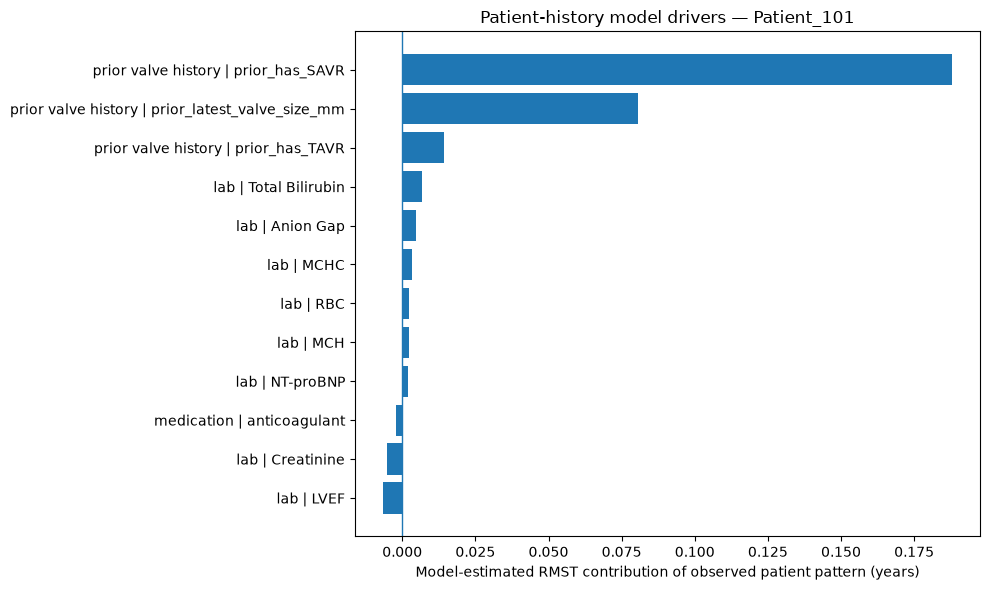

In [31]:
# ============================================================
# Plot top patient-history drivers
# ============================================================

top_drivers = (
    driver_df
    .head(12)
    .copy()
    .sort_values("effect_years")
)

labels = (
    top_drivers["modality"]
    + " | "
    + top_drivers["feature"]
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    labels,
    top_drivers["effect_years"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.xlabel(
    "Model-estimated RMST contribution of observed patient pattern (years)"
)

plt.title(
    f"Patient-history model drivers — {REAL_PATIENT_ID}"
)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# Exact Shapley explanation:
# why does candidate B differ from candidate A?
#
# Four feature groups only -> exact 2^4 coalition evaluation.
# ============================================================

FEATURE_GROUPS = [
    "candidate_procedure_type",
    "candidate_valve_model",
    "candidate_valve_size_mm",
    "candidate_valve_position",
]

# Default: compare second-highest estimate (A)
# with highest estimate (B).
if len(comparison_df) > 1:
    CANDIDATE_A_ID = comparison_df.iloc[1]["candidate_id"]
else:
    CANDIDATE_A_ID = comparison_df.iloc[0]["candidate_id"]

CANDIDATE_B_ID = comparison_df.iloc[0]["candidate_id"]

candidate_A = (
    candidate_demo[
        candidate_demo["candidate_id"].eq(
            CANDIDATE_A_ID
        )
    ]
    .iloc[0]
    .copy()
)

candidate_B = (
    candidate_demo[
        candidate_demo["candidate_id"].eq(
            CANDIDATE_B_ID
        )
    ]
    .iloc[0]
    .copy()
)


def hybrid_candidate(A, B, replaced_features):
    hybrid = A.copy()

    for feature in replaced_features:
        hybrid[feature] = B[feature]

    return hybrid


coalition_value = {}

for r in range(len(FEATURE_GROUPS) + 1):
    for subset_tuple in combinations(
        FEATURE_GROUPS,
        r,
    ):
        subset = frozenset(subset_tuple)

        hybrid = hybrid_candidate(
            candidate_A,
            candidate_B,
            subset,
        )

        coalition_value[subset] = predict_candidate(
            prepared_patient,
            history_tensor,
            hybrid,
        )["rmst_years"]


n = len(FEATURE_GROUPS)
shapley_rows = []

for feature in FEATURE_GROUPS:
    phi = 0.0

    others = [
        x
        for x in FEATURE_GROUPS
        if x != feature
    ]

    for r in range(len(others) + 1):
        for subset_tuple in combinations(
            others,
            r,
        ):
            S = frozenset(subset_tuple)
            S_with = S | {feature}

            weight = (
                math.factorial(len(S))
                * math.factorial(
                    n - len(S) - 1
                )
                / math.factorial(n)
            )

            marginal = (
                coalition_value[S_with]
                - coalition_value[S]
            )

            phi += weight * marginal

    shapley_rows.append({
        "candidate_feature": feature.replace(
            "candidate_",
            "",
        ),
        "shapley_delta_years": phi,
        "A_value": candidate_A[feature],
        "B_value": candidate_B[feature],
    })


shapley_df = pd.DataFrame(
    shapley_rows
)

rmst_A = coalition_value[
    frozenset()
]

rmst_B = coalition_value[
    frozenset(FEATURE_GROUPS)
]

print(
    "Candidate A:",
    CANDIDATE_A_ID,
    "|",
    round(rmst_A, 3),
    "years",
)

print(
    "Candidate B:",
    CANDIDATE_B_ID,
    "|",
    round(rmst_B, 3),
    "years",
)

print(
    "Predicted durability difference B - A:",
    round(
        rmst_B - rmst_A,
        3,
    ),
    "years",
)

display(
    shapley_df.sort_values(
        "shapley_delta_years",
        ascending=False,
    )
)

assert np.isclose(
    shapley_df["shapley_delta_years"].sum(),
    rmst_B - rmst_A,
    atol=1e-5,
)

Candidate A: OBS_006 | 10.464 years
Candidate B: OBS_013 | 10.753 years
Predicted durability difference B - A: 0.289 years


,candidate_feature,shapley_delta_years,A_value,B_value
2,valve_size_mm,0.131742,25.0,29.0
0,procedure_type,0.090558,SAVR,TAVR
1,valve_model,0.066581,Carpentier-Edwards pericardial,Edwards-Sapien
3,valve_position,0.000000,aortic,aortic


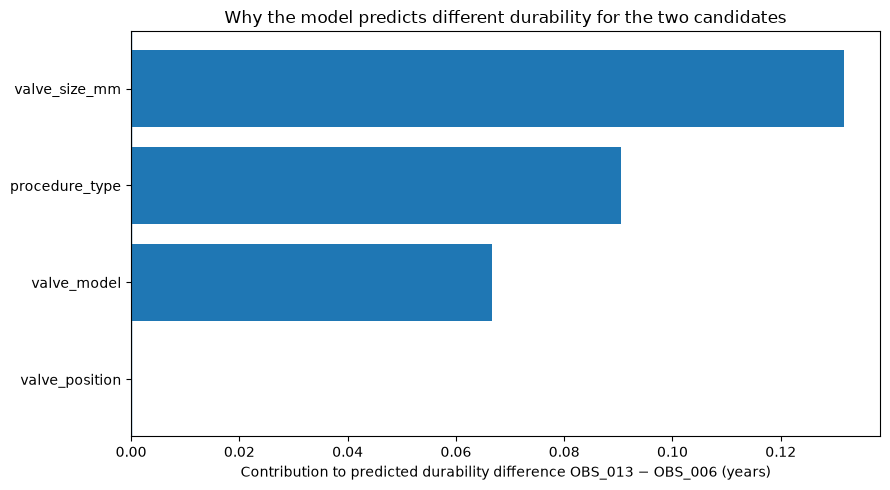

In [33]:
# ============================================================
# Plot candidate-comparison Shapley attribution
# ============================================================

plot_shap = (
    shapley_df
    .sort_values("shapley_delta_years")
)

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    plot_shap["candidate_feature"],
    plot_shap["shapley_delta_years"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.xlabel(
    f"Contribution to predicted durability difference "
    f"{CANDIDATE_B_ID} − {CANDIDATE_A_ID} (years)"
)

plt.title(
    "Why the model predicts different durability for the two candidates"
)

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Compact doctor-facing summary
# ============================================================

top_row = comparison_df.iloc[0]

print("=" * 72)
print("VALVE DURABILITY — MODEL DEMONSTRATION")
print("=" * 72)

print(f"Patient: {REAL_PATIENT_ID}")
print(
    f"Pre-operative history: "
    f"{prepared_patient['lab'].shape[0]} yearly observations"
)

print(
    "\nHighest model-estimated durability among evaluated candidates:"
)

print(
    f"  {top_row['candidate_id']} | "
    f"{top_row['procedure_type']} | "
    f"{top_row['valve_model']} | "
    f"{top_row['valve_size_mm']} mm"
)

print(
    f"  {HORIZON_YEARS:.0f}-year RMST: "
    f"{top_row['estimated_event_free_years_12y_rmst']:.2f} years"
)

print(
    f"  Event-free probability: "
    f"5y={100*top_row['survival_5y']:.1f}% | "
    f"8y={100*top_row['survival_8y']:.1f}% | "
    f"10y={100*top_row['survival_10y']:.1f}%"
)

print("\nLargest patient-history model drivers:")

for _, row in driver_df.head(5).iterrows():
    direction = (
        "longer"
        if row["effect_years"] > 0
        else "shorter"
    )

    print(
        f"  {row['modality']} | {row['feature']}: "
        f"{row['effect_years']:+.2f} y "
        f"({direction} predicted durability)"
    )

print("\nCandidate comparison explanation:")

print(
    f"  {CANDIDATE_B_ID} - {CANDIDATE_A_ID}: "
    f"{rmst_B-rmst_A:+.2f} predicted years"
)

for _, row in shapley_df.sort_values(
    "shapley_delta_years",
    ascending=False,
).iterrows():
    print(
        f"  {row['candidate_feature']}: "
        f"{row['shapley_delta_years']:+.2f} y"
    )

print(
    "\nIMPORTANT: semi-synthetic proof-of-concept; "
    "not clinically validated and not a treatment recommendation."
)

print("=" * 72)

VALVE DURABILITY — MODEL DEMONSTRATION
Patient: Patient_101
Pre-operative history: 21 yearly observations

Highest model-estimated durability among evaluated candidates:
  OBS_013 | TAVR | Edwards-Sapien | 29.0 mm
  12-year RMST: 10.75 years
  Event-free probability: 5y=98.3% | 8y=92.3% | 10y=62.8%

Largest patient-history model drivers:
  prior valve history | prior_has_SAVR: +0.19 y (longer predicted durability)
  prior valve history | prior_latest_valve_size_mm: +0.08 y (longer predicted durability)
  prior valve history | prior_has_TAVR: +0.01 y (longer predicted durability)
  lab | Total Bilirubin: +0.01 y (longer predicted durability)
  lab | LVEF: -0.01 y (shorter predicted durability)

Candidate comparison explanation:
  OBS_013 - OBS_006: +0.29 predicted years
  valve_size_mm: +0.13 y
  procedure_type: +0.09 y
  valve_model: +0.07 y
  valve_position: +0.00 y

IMPORTANT: semi-synthetic proof-of-concept; not clinically validated and not a treatment recommendation.


In [35]:
# ============================================================
# Export hackathon-demo artifacts
# ============================================================

doctor_table_path = (
    DEMO_OUT
    / f"{REAL_PATIENT_ID}_candidate_comparison.csv"
)

driver_path = (
    DEMO_OUT
    / f"{REAL_PATIENT_ID}_history_drivers.csv"
)

shapley_path = (
    DEMO_OUT
    / (
        f"{REAL_PATIENT_ID}_"
        f"{CANDIDATE_A_ID}_vs_{CANDIDATE_B_ID}_"
        "valve_shapley.csv"
    )
)

summary_path = (
    DEMO_OUT
    / f"{REAL_PATIENT_ID}_demo_summary.json"
)

doctor_table.to_csv(
    doctor_table_path,
    index=False,
)

driver_df.to_csv(
    driver_path,
    index=False,
)

shapley_df.to_csv(
    shapley_path,
    index=False,
)

summary = {
    "patient": REAL_PATIENT_ID,

    "hypothetical_surgery_year": float(
        prepared_patient["surgery_year"]
    ),

    "n_longitudinal_observations": int(
        prepared_patient["lab"].shape[0]
    ),

    "highest_model_estimate": {
        "candidate_id": top_row["candidate_id"],
        "procedure_type": top_row["procedure_type"],
        "valve_model": top_row["valve_model"],

        "valve_size_mm": (
            None
            if pd.isna(top_row["valve_size_mm"])
            else float(top_row["valve_size_mm"])
        ),

        "rmst_years_horizon": float(
            top_row[
                "estimated_event_free_years_12y_rmst"
            ]
        ),

        "survival_5y": float(
            top_row["survival_5y"]
        ),

        "survival_8y": float(
            top_row["survival_8y"]
        ),

        "survival_10y": float(
            top_row["survival_10y"]
        ),
    },

    "candidate_pair_explanation": {
        "candidate_A": CANDIDATE_A_ID,
        "candidate_B": CANDIDATE_B_ID,

        "delta_rmst_years_B_minus_A": float(
            rmst_B - rmst_A
        ),
    },

    "disclaimer": (
        "Semi-synthetic proof-of-concept. "
        "Not clinically validated and not a treatment recommendation."
    ),
}

with open(
    summary_path,
    "w",
) as f:
    json.dump(
        summary,
        f,
        indent=2,
    )

print("Saved:")
print("✓", doctor_table_path)
print("✓", driver_path)
print("✓", shapley_path)
print("✓", summary_path)

Saved:
✓ doctor_facing_demo/Patient_101_candidate_comparison.csv
✓ doctor_facing_demo/Patient_101_history_drivers.csv
✓ doctor_facing_demo/Patient_101_OBS_006_vs_OBS_013_valve_shapley.csv
✓ doctor_facing_demo/Patient_101_demo_summary.json


## Suggested live demo flow

1. **Select a patient** and show the longitudinal lab/medication record plus Qwen-derived prior valve history.
2. **Evaluate candidate valves** and show model-estimated RMST plus 5/8/10-year event-free probabilities.
3. **Show survival curves** for the same patient under different proposed valves.
4. **Explain the patient prediction** with the highest-sensitivity longitudinal/history features.
5. **Compare two valves directly** with the exact Shapley decomposition.
6. End with the frozen `03b` semi-synthetic validation:
   - C-index ≈ **0.863**
   - within-patient Spearman ≈ **0.823**
   - top-choice recovery ≈ **76%**
   - pairwise candidate ranking ≈ **88.3%**

Use **model-estimated event-free durability**, not “guaranteed valve lifespan.”